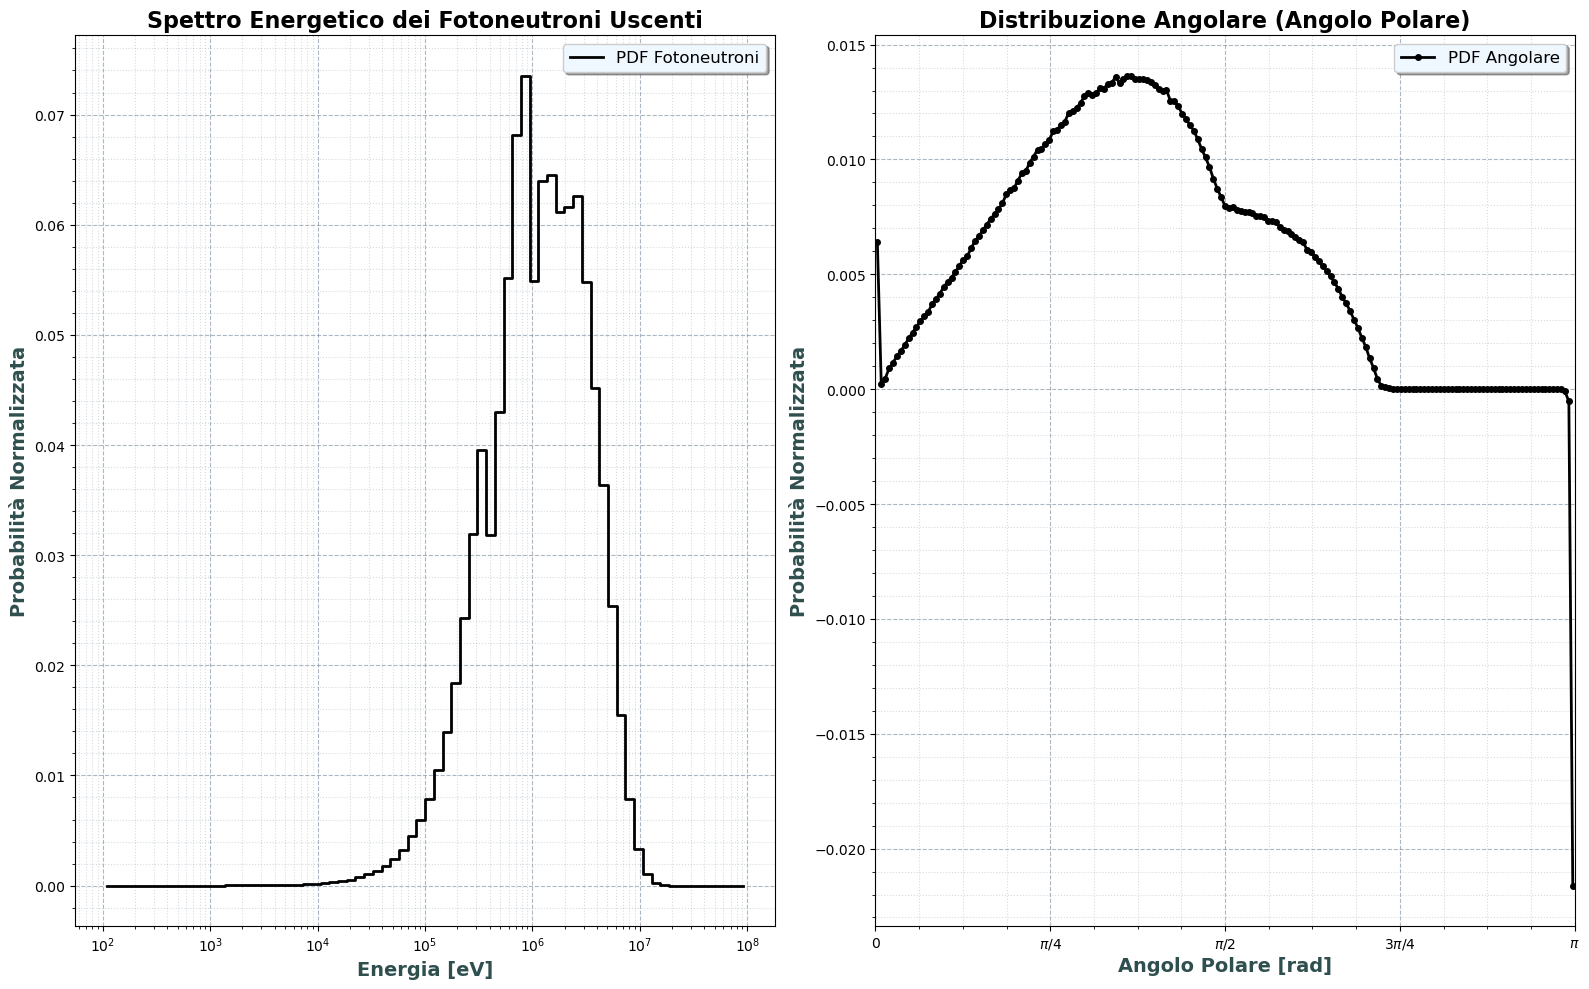

Yield fotoneutronico calcolato: 7.43891e-03 neutroni per fotone sorgente


In [39]:
import os
import glob
import openmc
import numpy as np
import matplotlib.pyplot as plt

energy_bins = np.logspace(2, 8, 75)
polar_bins = np.linspace(0, np.pi, 180)

# Calcolo dei centri dei bin (media geometrica per scala logaritmica)
energy_midpoints = np.sqrt(energy_bins[:-1] * energy_bins[1:])
# Media aritmetica per scala lineare
polar_midpoints = 0.5 * (polar_bins[:-1] + polar_bins[1:])

# Trova l'ultimo statepoint generato
sp_files = glob.glob('statepoint.*.h5')
if not sp_files:
    raise FileNotFoundError("Nessun file statepoint trovato. La simulazione è fallita.")
latest_sp = max(sp_files, key=os.path.getctime)

# Caricamento risultati
with openmc.StatePoint(latest_sp) as sp:
    # --- Spettro Energetico ---
    t_e = sp.get_tally(name='spettro_energia_neutroni')
    # Correzione: reshape e somma sulle 3 superfici anche per l'energia
    current_e = t_e.mean.flatten().reshape(3, len(energy_midpoints)).sum(axis=0)
    
    # --- Spettro Angolare ---
    t_a = sp.get_tally(name='spettro_angolare_neutroni') # o 'spettro_angolare_neutroni' in base a come lo hai chiamato
    current_a = t_a.mean.flatten().reshape(3, len(polar_midpoints)).sum(axis=0)

# Calcolo dello yield totale (Integrale della corrente uscente)
sum_e = np.sum(current_e)
sum_a = np.sum(current_a)

# Normalizzazione a PDF (Probability Density Function)
pdf_e = current_e / sum_e if sum_e > 0 else current_e
pdf_a = current_a / sum_a if sum_a > 0 else current_a 

# Salvataggio su file di testo
np.savetxt("photoneutrons_energy.txt", np.column_stack((energy_midpoints, pdf_e)), 
           header="Energy_eV PDF", comments="")
np.savetxt("photoneutrons_polar.txt", np.column_stack((polar_midpoints, pdf_a)), 
           header="Polar_Angle_rad PDF", comments="")


# =====================================================================
# PLOTTING DEI RISULTATI
# =====================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# --- Plot Energetico ---
ax1.step(energy_midpoints, pdf_e, where='mid', color='#000000', lw=2, label='PDF Fotoneutroni')
ax1.set_xscale('log')
ax1.set_title("Spettro Energetico dei Fotoneutroni Uscenti", fontsize=16, fontweight='bold')
ax1.set_xlabel("Energia [eV]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax1.set_ylabel("Probabilità Normalizzata", fontsize=14, fontweight='bold', color='#2F4F4F')

ax1.minorticks_on()
ax1.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax1.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax1.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# --- Plot Angolare ---
ax2.plot(polar_midpoints, pdf_a, color='#000000', lw=2, marker='o', markersize=4, label='PDF Angolare')
ax2.set_title("Distribuzione Angolare (Angolo Polare)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Angolo Polare [rad]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_ylabel("Probabilità Normalizzata", fontsize=14, fontweight='bold', color='#2F4F4F')

# Estetica asse angolare
ax2.set_xlim(0, np.pi)
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])

ax2.minorticks_on()
ax2.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax2.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax2.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()

print(f"Yield fotoneutronico calcolato: {sum_a:.5e} neutroni per fotone sorgente")


In [33]:
'''
Nei codici Monte Carlo come OpenMC, i risultati dei tally sono intrinsecamente normalizzati
per particella di sorgente simulata. Nello Step 1 la tua sorgente era un singolo fotone. 
Il tally di corrente (current_a) misurava i neutroni che attraversavano la superficie esterna del target. 
Di conseguenza, la loro somma totale, ovvero sum_a, rappresenta la resa fotoneutronica integrale del bersaglio.
Fisicamente, sum_a risponde alla domanda: "Quanti neutroni utili ottengo per ogni singolo fotone 
primario emesso dal sincrotrone?" (Troverai un valore molto minore di 1, tipicamente dell'ordine di 0.01).
'''

'\nNei codici Monte Carlo come OpenMC, i risultati dei tally sono intrinsecamente normalizzati\nper particella di sorgente simulata. Nello Step 1 la tua sorgente era un singolo fotone. \nIl tally di corrente (current_a) misurava i neutroni che attraversavano la superficie esterna del target. \nDi conseguenza, la loro somma totale, ovvero sum_a, rappresenta la resa fotoneutronica integrale del bersaglio.\nFisicamente, sum_a risponde alla domanda: "Quanti neutroni utili ottengo per ogni singolo fotone \nprimario emesso dal sincrotrone?" (Troverai un valore molto minore di 1, tipicamente dell\'ordine di 0.01).\n'

Dati estratti e salvati con successo.


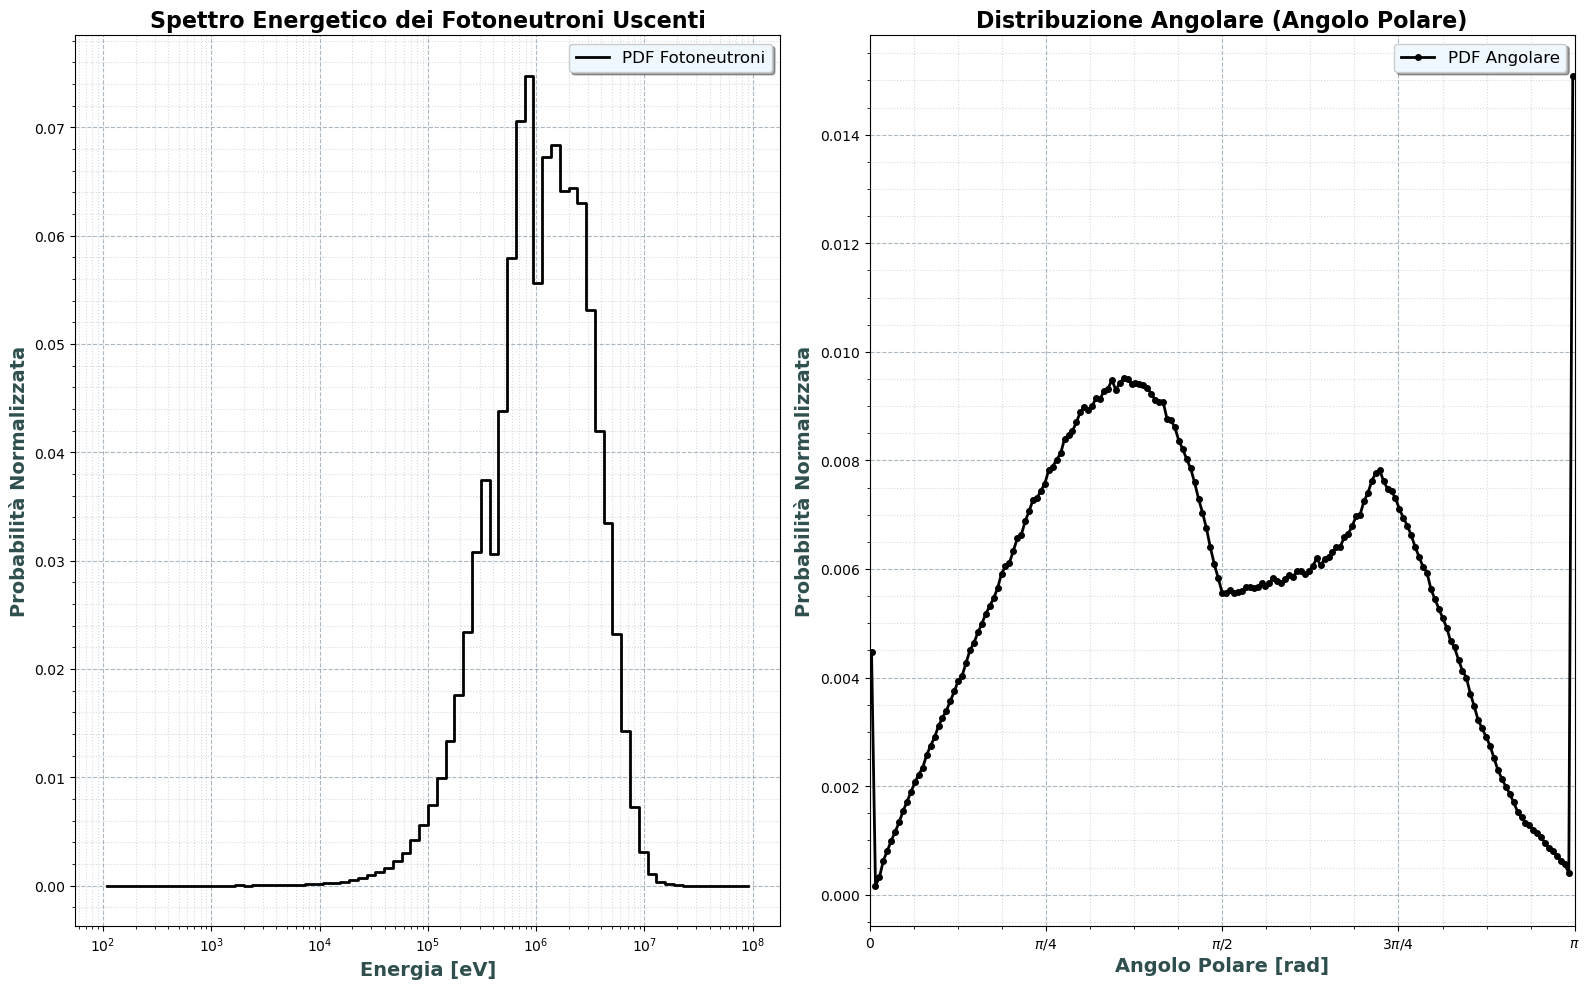

Yield fotoneutronico calcolato: 1.06587e-02 neutroni per fotone sorgente


In [40]:
import os
import glob
import openmc
import numpy as np
import matplotlib.pyplot as plt

energy_bins = np.logspace(2, 8, 75)
polar_bins = np.linspace(0, np.pi, 180)

# Calcolo dei centri dei bin
energy_midpoints = np.sqrt(energy_bins[:-1] * energy_bins[1:])
polar_midpoints = 0.5 * (polar_bins[:-1] + polar_bins[1:])

sp_files = glob.glob('statepoint.*.h5')
if not sp_files:
    raise FileNotFoundError("Nessun file statepoint trovato.")
latest_sp = max(sp_files, key=os.path.getctime)

with openmc.StatePoint(latest_sp) as sp:
    # --- Spettro Energetico ---
    t_e = sp.get_tally(name='spettro_energia_neutroni')
    # Estrazione numpy, valore assoluto e somma sulle 3 superfici
    val_e = np.abs(t_e.mean.flatten())
    current_e = val_e.reshape(3, len(energy_midpoints)).sum(axis=0)
    
    # --- Spettro Angolare ---
    t_a = sp.get_tally(name='spettro_angolare_neutroni') 
    val_a = np.abs(t_a.mean.flatten())
    current_a = val_a.reshape(3, len(polar_midpoints)).sum(axis=0)

# Calcolo dello yield totale e normalizzazione a PDF
sum_e = np.sum(current_e)
sum_a = np.sum(current_a)

pdf_e = current_e / sum_e if sum_e > 0 else current_e
pdf_a = current_a / sum_a if sum_a > 0 else current_a

# Salvataggio
np.savetxt("photoneutrons_energy.txt", np.column_stack((energy_midpoints, pdf_e)), 
           header="Energy_eV PDF", comments="")
np.savetxt("photoneutrons_polar.txt", np.column_stack((polar_midpoints, pdf_a)), 
           header="Polar_Angle_rad PDF", comments="")

print("Dati estratti e salvati con successo.")

# =====================================================================
# PLOTTING DEI RISULTATI
# =====================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# --- Plot Energetico ---
ax1.step(energy_midpoints, pdf_e, where='mid', color='#000000', lw=2, label='PDF Fotoneutroni')
ax1.set_xscale('log')
ax1.set_title("Spettro Energetico dei Fotoneutroni Uscenti", fontsize=16, fontweight='bold')
ax1.set_xlabel("Energia [eV]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax1.set_ylabel("Probabilità Normalizzata", fontsize=14, fontweight='bold', color='#2F4F4F')

ax1.minorticks_on()
ax1.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax1.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax1.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# --- Plot Angolare ---
ax2.plot(polar_midpoints, pdf_a, color='#000000', lw=2, marker='o', markersize=4, label='PDF Angolare')
ax2.set_title("Distribuzione Angolare (Angolo Polare)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Angolo Polare [rad]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_ylabel("Probabilità Normalizzata", fontsize=14, fontweight='bold', color='#2F4F4F')

ax2.set_xlim(0, np.pi)
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])

ax2.minorticks_on()
ax2.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax2.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax2.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()

print(f"Yield fotoneutronico calcolato: {sum_a:.5e} neutroni per fotone sorgente")

Totale neutroni fisicamente uscenti (Corrente netta): 1.06587e-02


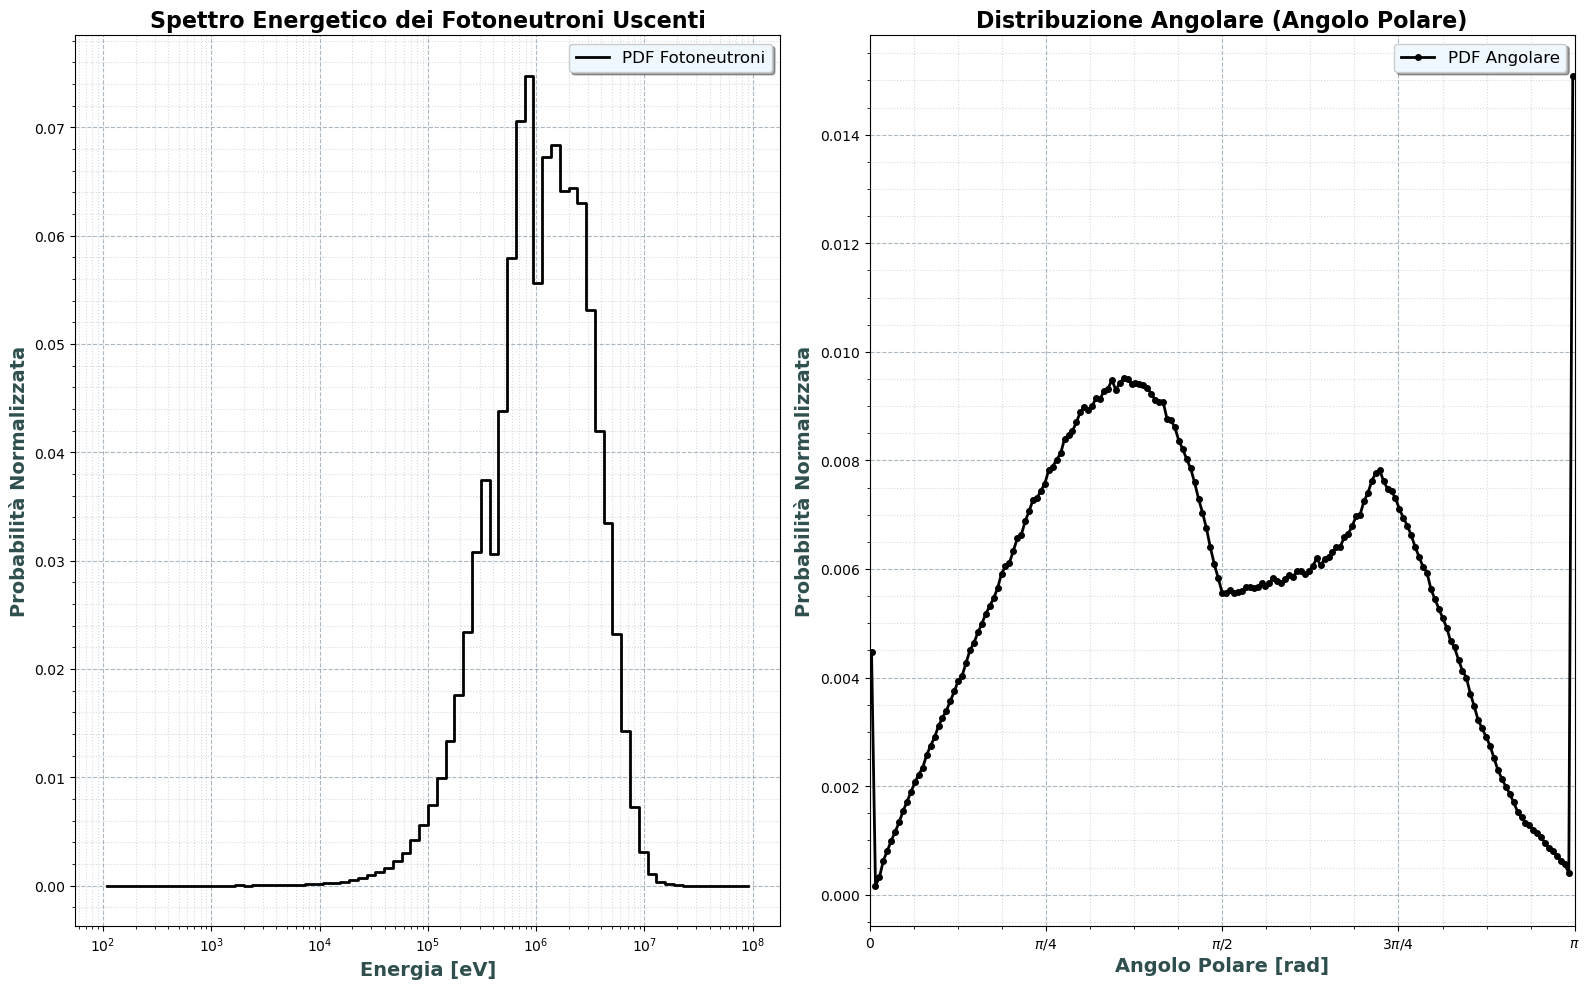

In [41]:
import os
import glob
import openmc
import numpy as np
import matplotlib.pyplot as plt

energy_bins = np.logspace(2, 8, 75)
polar_bins = np.linspace(0, np.pi, 180)

energy_midpoints = np.sqrt(energy_bins[:-1] * energy_bins[1:])
polar_midpoints = 0.5 * (polar_bins[:-1] + polar_bins[1:])

sp_files = glob.glob('statepoint.*.h5')
if not sp_files:
    raise FileNotFoundError("Nessun file statepoint trovato.")
latest_sp = max(sp_files, key=os.path.getctime)

with openmc.StatePoint(latest_sp) as sp:
    # --- Spettro Energetico ---
    t_e = sp.get_tally(name='spettro_energia_neutroni')
    val_e = np.abs(t_e.mean.flatten())
    current_e = val_e.reshape(3, len(energy_midpoints)).sum(axis=0)
    
    # --- Spettro Angolare ---
    t_a = sp.get_tally(name='spettro_angolare_neutroni') 
    val_a = np.abs(t_a.mean.flatten())
    current_a = val_a.reshape(3, len(polar_midpoints)).sum(axis=0)

sum_e = np.sum(current_e)
sum_a = np.sum(current_a)

print(f"Totale neutroni fisicamente uscenti (Corrente netta): {sum_a:.5e}")

pdf_e = current_e / sum_e if sum_e > 0 else current_e
pdf_a = current_a / sum_a if sum_a > 0 else current_a

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

ax1.step(energy_midpoints, pdf_e, where='mid', color='#000000', lw=2, label='PDF Fotoneutroni')
ax1.set_xscale('log')
ax1.set_title("Spettro Energetico dei Fotoneutroni Uscenti", fontsize=16, fontweight='bold')
ax1.set_xlabel("Energia [eV]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax1.set_ylabel("Probabilità Normalizzata", fontsize=14, fontweight='bold', color='#2F4F4F')
ax1.minorticks_on()
ax1.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax1.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax1.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

ax2.plot(polar_midpoints, pdf_a, color='#000000', lw=2, marker='o', markersize=4, label='PDF Angolare')
ax2.set_title("Distribuzione Angolare (Angolo Polare)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Angolo Polare [rad]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_ylabel("Probabilità Normalizzata", fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_xlim(0, np.pi)
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax2.minorticks_on()
ax2.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax2.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax2.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()